# 01 — Exploratory Data Analysis
**Author:** Ricardo Sanchez  

**Project:** Monetary Policy Shocks and Startup Funding Transitions (Seed → Series A)

**Date:** March 03, 2026 

**Data source:** Crunchbase (2016 – 2023 Q3) 

**Sectors:** FinTech, AI

---

## Inputs

**Startup data (Crunchbase)**
- `data/raw/fintech/fintech_seed_funding_package_A.csv`
- `data/raw/fintech/fintech_seed_funding_package_B.csv`
- `data/raw/fintech/fintech_series_A_funding.csv`
- `data/raw/AI/ai_seed_package_A.csv`
- `data/raw/AI/ai_seed_package_B.csv`
- `data/raw/AI/ai_series_A_funding_package_A.csv`
- `data/raw/AI/ai_series_A_funding_package_B.xlsx`

**Macro data**
- `data/raw/macro/monitary_shock.csv` — Monetary policy shocks (quarterly, 2014 Q1 – 2023 Q3)
- `data/raw/macro/core_cpi.csv` — Core CPI year-over-year % change (quarterly, 2015 Q1 – 2025 Q3)
- `data/raw/macro/real_gdp.csv` — Real GDP year-over-year % change (quarterly, 2015 Q1 – 2025 Q3)

## Outputs
- None (exploration only — all outputs are inline)

## 1. Setup & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

# ── Paths (relative to notebook location inside notebooks/) ──
from pathlib import Path

PROJECT_ROOT = Path("..")
RAW_FT       = PROJECT_ROOT / "data" / "raw" / "fintech"
RAW_AI       = PROJECT_ROOT / "data" / "raw" / "AI"
RAW_MACRO    = PROJECT_ROOT / "data" / "raw" / "macro"

# ── Observation window ──
OBS_START = pd.Timestamp("2016-01-01")
OBS_END   = pd.Timestamp("2023-09-30")

# ── Plot style ──
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
COLORS = {"FinTech": "#1b9e77", "AI": "#d95f02"}

---

# Part A — Startup Data (Crunchbase)

## 2. Load Raw Data

We load every raw Crunchbase export **before any cleaning**. Each sector has
seed-round and Series A packages that were downloaded in batches.

In [3]:
# ── FinTech ──
ft_seed_a  = pd.read_csv(RAW_FT / "fintech_seed_funding_package_A.csv")
ft_seed_b  = pd.read_csv(RAW_FT / "fintech_seed_funding_package_B.csv")
ft_seriesa = pd.read_csv(RAW_FT / "fintech_series_A_funding.csv")

ft_seed = pd.concat([ft_seed_a, ft_seed_b], ignore_index=True)

# ── AI ──
ai_seed_a  = pd.read_csv(RAW_AI / "ai_seed_package_A.csv")
ai_seed_b  = pd.read_csv(RAW_AI / "ai_seed_package_B.csv")
ai_sa_a    = pd.read_csv(RAW_AI / "ai_series_A_funding_package_A.csv")
ai_sa_b    = pd.read_excel(RAW_AI / "ai_series_A_funding_package_B.xlsx")

ai_seed    = pd.concat([ai_seed_a, ai_seed_b], ignore_index=True)
ai_seriesa = pd.concat([ai_sa_a, ai_sa_b], ignore_index=True)

# Collect in a dict for easy iteration
datasets = {
    "FinTech Seed":     ft_seed,
    "FinTech Series A": ft_seriesa,
    "AI Seed":          ai_seed,
    "AI Series A":      ai_seriesa,
}

for name, df in datasets.items():
    print(f"{name:20s} →  {df.shape[0]:,} rows  ×  {df.shape[1]} cols")

FinTech Seed         →  1,335 rows  ×  16 cols
FinTech Series A     →  606 rows  ×  16 cols
AI Seed              →  1,532 rows  ×  14 cols
AI Series A          →  683 rows  ×  14 cols


## 3. Schema Comparison

Before anything else, check whether the fintech and AI exports share the
same column names. Mismatches here will cause silent bugs downstream.

In [4]:
# Build a column-presence matrix across all four raw datasets
all_cols = sorted(set().union(*(df.columns for df in datasets.values())))

schema = pd.DataFrame(
    {name: [col in df.columns for col in all_cols] for name, df in datasets.items()},
    index=all_cols,
)

# Flag columns that are NOT present in every dataset
schema["in_all"] = schema.all(axis=1)

print("Columns present in ALL datasets:")
print(schema[schema["in_all"]].index.tolist())
print()

mismatches = schema[~schema["in_all"]]
if len(mismatches):
    print(f"⚠  {len(mismatches)} column(s) NOT shared across all datasets:")
    print(mismatches)
else:
    print("✓  All datasets share the same columns.")

Columns present in ALL datasets:
['Announced Date', 'Diversity Spotlight', 'Funding Type', 'Money Raised', 'Money Raised (in USD)', 'Money Raised Currency', 'Number of Investors', 'Number of Partner Investors', 'Organization Location', 'Organization Name', 'Organization Name URL', 'Transaction Name', 'Transaction Name URL']

⚠  4 column(s) NOT shared across all datasets:
                            FinTech Seed  FinTech Series A  AI Seed  AI Series A  in_all
Equity Only Funding                 True              True    False        False   False
Investor Names                     False             False     True         True   False
Organization Revenue Range          True              True    False        False   False
Organization Website                True              True    False        False   False


In [5]:
# Dtype comparison for shared columns
# (catches cases where the same column is string in one file, numeric in another)
shared_cols = schema[schema["in_all"]].index.tolist()

dtype_df = pd.DataFrame(
    {name: df[shared_cols].dtypes.astype(str) for name, df in datasets.items()}
)
dtype_mismatches = dtype_df[dtype_df.nunique(axis=1) > 1]

if len(dtype_mismatches):
    print(f"⚠  {len(dtype_mismatches)} column(s) with dtype mismatches across datasets:")
    print(dtype_mismatches)
else:
    print("✓  All shared columns have consistent dtypes.")

⚠  4 column(s) with dtype mismatches across datasets:
                            FinTech Seed FinTech Series A  AI Seed AI Series A
Money Raised                       int64            int64    int64      object
Money Raised (in USD)              int64            int64    int64     float64
Number of Investors              float64          float64  float64      object
Number of Partner Investors      float64          float64  float64      object


## 4. Row Counts & Package Overlap

Each sector's seed data came in two download batches (package A + B).
Check whether they overlap or are disjoint, and whether any rows are
exact duplicates.

In [6]:
# ── FinTech seed: package overlap ──
ft_overlap = pd.merge(ft_seed_a, ft_seed_b, how="inner",
                      on=["Organization Name", "Announced Date"])
print(f"FinTech seed pkg A: {len(ft_seed_a):,}  |  pkg B: {len(ft_seed_b):,}  "
      f"|  overlap (org + date): {len(ft_overlap):,}")

# Full duplicate rows in merged fintech seed
ft_dupes = ft_seed[ft_seed.duplicated(keep=False)]
print(f"FinTech seed exact duplicate rows: {len(ft_dupes) // 2}")
print()

# ── AI seed: package overlap ──
ai_overlap = pd.merge(ai_seed_a, ai_seed_b, how="inner",
                      on=["Organization Name", "Announced Date"])
print(f"AI seed pkg A: {len(ai_seed_a):,}  |  pkg B: {len(ai_seed_b):,}  "
      f"|  overlap (org + date): {len(ai_overlap):,}")

ai_dupes = ai_seed[ai_seed.duplicated(keep=False)]
print(f"AI seed exact duplicate rows: {len(ai_dupes) // 2}")
print()

# ── AI Series A: package overlap ──
ai_sa_overlap = pd.merge(ai_sa_a, ai_sa_b, how="inner",
                         on=["Organization Name", "Announced Date"])
print(f"AI Series A pkg A: {len(ai_sa_a):,}  |  pkg B: {len(ai_sa_b):,}  "
      f"|  overlap (org + date): {len(ai_sa_overlap):,}")

FinTech seed pkg A: 1,000  |  pkg B: 335  |  overlap (org + date): 0
FinTech seed exact duplicate rows: 0

AI seed pkg A: 1,000  |  pkg B: 532  |  overlap (org + date): 3
AI seed exact duplicate rows: 3

AI Series A pkg A: 468  |  pkg B: 215  |  overlap (org + date): 0


## 5. Funding Type Sanity Check

The raw exports are supposed to contain only "Seed" or "Series A"
transactions, but Crunchbase downloads sometimes include adjacent
round types. Verify before filtering.

In [7]:
for name, df in datasets.items():
    print(f"── {name} ──")
    if "Funding Type" in df.columns:
        print(df["Funding Type"].value_counts().to_string())
    else:
        print("  (no 'Funding Type' column)")
    print()

── FinTech Seed ──
Funding Type
Seed    1335

── FinTech Series A ──
Funding Type
Series A    606

── AI Seed ──
Funding Type
Seed    1532

── AI Series A ──
Funding Type
Series A    683



## 6. Date Ranges

Our observation window is **2016-01-01 to 2023-09-30**. Check whether
the raw data falls within this range or spills beyond it.

In [8]:
for name, df in datasets.items():
    if "Announced Date" in df.columns:
        dates = pd.to_datetime(df["Announced Date"], errors="coerce")
        n_bad = dates.isna().sum() - df["Announced Date"].isna().sum()
        print(f"{name:20s}  →  {dates.min():%Y-%m-%d}  to  {dates.max():%Y-%m-%d}"
              f"   |  unparseable: {n_bad}")

FinTech Seed          →  2016-01-01  to  2024-12-17   |  unparseable: 0
FinTech Series A      →  2016-01-01  to  2024-12-16   |  unparseable: 0
AI Seed               →  2016-01-01  to  2024-12-19   |  unparseable: 0
AI Series A           →  2016-01-05  to  2022-04-15   |  unparseable: 215


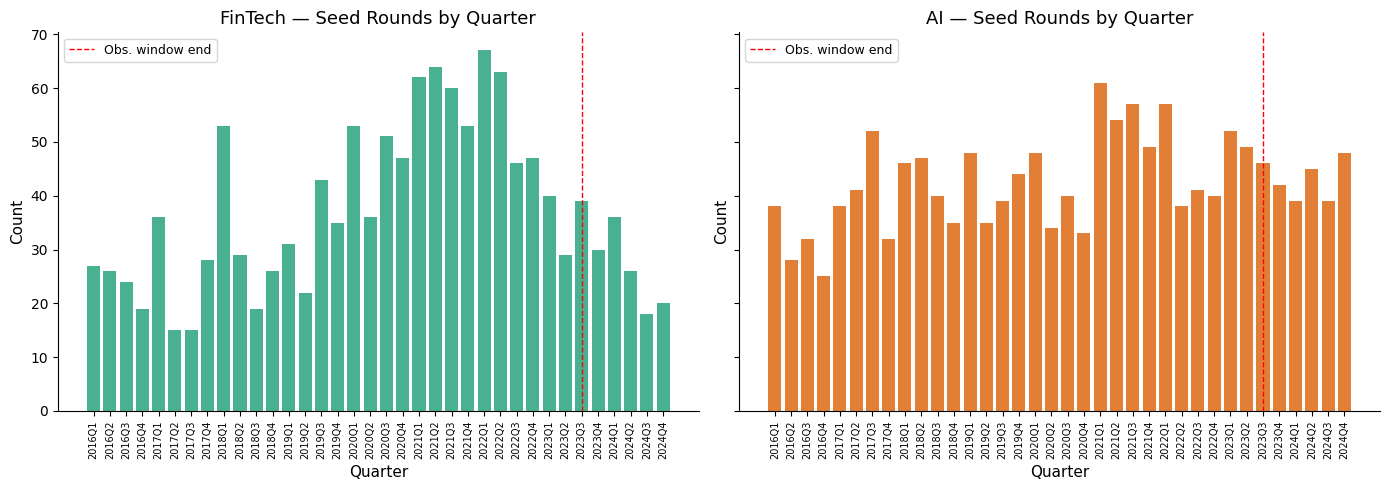

In [9]:
# ── Timeline histogram: all seed rounds by quarter ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (label, df) in zip(axes, [("FinTech", ft_seed), ("AI", ai_seed)]):
    dates = pd.to_datetime(df["Announced Date"], errors="coerce").dropna()
    quarters = dates.dt.to_period("Q").value_counts().sort_index()
    ax.bar(quarters.index.astype(str), quarters.values, color=COLORS[label], alpha=0.8)
    ax.set_title(f"{label} — Seed Rounds by Quarter")
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    # Mark observation window boundary
    ax.axvline(x="2023Q3", color="red", linestyle="--", linewidth=1, label="Obs. window end")
    ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## 7. Missing Values

Identify which columns have significant missingness. Key variables for
the downstream survival model are: **Announced Date, Organization Name,
Money Raised (in USD), Organization Location, Number of Partner
Investors, Diversity Spotlight**.

In [10]:
key_cols = [
    "Announced Date", "Organization Name", "Organization Location",
    "Money Raised (in USD)", "Funding Type",
    "Number of Partner Investors", "Number of Investors",
    "Diversity Spotlight"
]

rows = []
for name, df in datasets.items():
    for col in key_cols:
        if col in df.columns:
            n_miss = df[col].isna().sum()
            pct = n_miss / len(df) * 100
            rows.append({"Dataset": name, "Column": col,
                         "Missing": n_miss, "% Missing": round(pct, 1)})

miss_df = pd.DataFrame(rows)
# Only show columns with >0 missing
miss_df = miss_df[miss_df["Missing"] > 0]

if len(miss_df):
    print(miss_df.pivot_table(index="Column", columns="Dataset",
                               values="% Missing", fill_value=0)
           .round(1).to_string())
else:
    print("✓  No missing values in key columns across any dataset.")

Dataset                      AI Seed  AI Series A  FinTech Seed  FinTech Series A
Column                                                                           
Diversity Spotlight             74.3         52.0          74.2              74.4
Money Raised (in USD)            0.0         31.5           0.0               0.0
Number of Investors             19.6          1.2          18.2               4.5
Number of Partner Investors     59.3         20.9          57.2              23.6


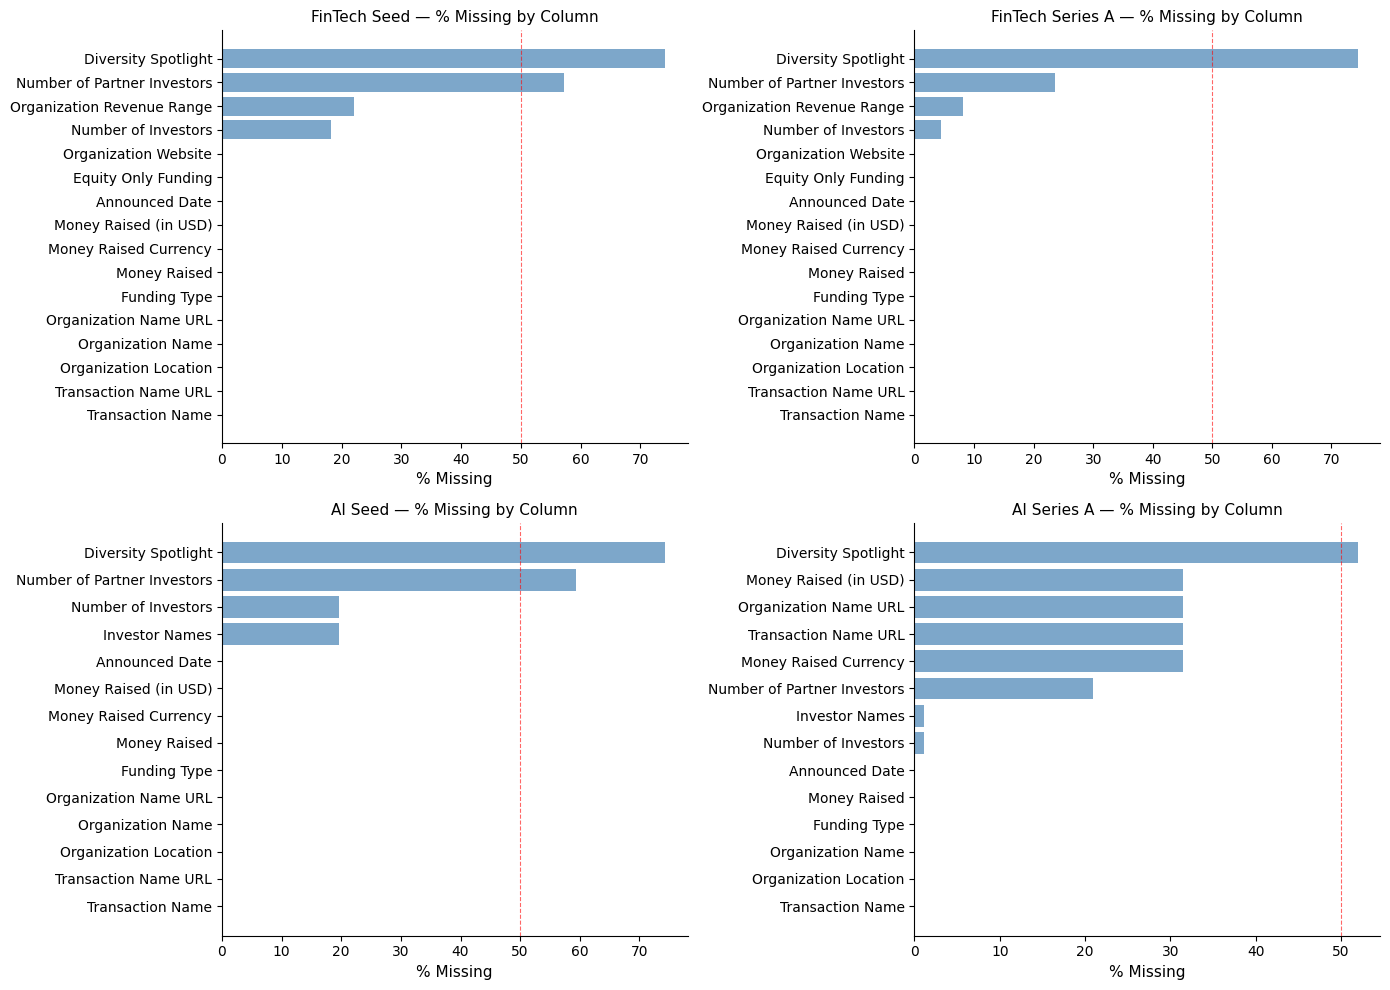

In [11]:
# ── Heatmap-style missing value overview (all columns) ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, df) in zip(axes.flatten(), datasets.items()):
    pct_missing = (df.isna().sum() / len(df) * 100).sort_values(ascending=True)
    bars = ax.barh(pct_missing.index, pct_missing.values, color="steelblue", alpha=0.7)
    ax.set_title(f"{name} — % Missing by Column", fontsize=11)
    ax.set_xlabel("% Missing")
    ax.axvline(x=50, color="red", linestyle="--", linewidth=0.8, alpha=0.6)

fig.tight_layout()
plt.show()

## 8. Duplicate Organizations

Startups may appear more than once in the seed data if they had multiple
seed rounds. We need to know this before collapsing to one row per firm
in the cleaning notebook.

In [12]:
for label, df in [("FinTech Seed", ft_seed), ("AI Seed", ai_seed)]:
    vc = df["Organization Name"].value_counts()
    n_multi = (vc > 1).sum()
    max_rounds = vc.max()
    print(f"{label}:  {len(vc):,} unique orgs  |  {n_multi} with multiple seed rounds  "
          f"|  max rounds per org: {max_rounds}")

print()

for label, df in [("FinTech Series A", ft_seriesa), ("AI Series A", ai_seriesa)]:
    vc = df["Organization Name"].value_counts()
    n_multi = (vc > 1).sum()
    print(f"{label}:  {len(vc):,} unique orgs  |  {n_multi} with multiple Series A rounds")

FinTech Seed:  1,034 unique orgs  |  237 with multiple seed rounds  |  max rounds per org: 7
AI Seed:  1,173 unique orgs  |  271 with multiple seed rounds  |  max rounds per org: 6

FinTech Series A:  536 unique orgs  |  61 with multiple Series A rounds
AI Series A:  601 unique orgs  |  73 with multiple Series A rounds


In [13]:
# ── How many seed-funded startups also appear in Series A? ──
ft_seed_orgs = set(ft_seed["Organization Name"].unique())
ft_sa_orgs   = set(ft_seriesa["Organization Name"].unique())
ft_matched   = ft_seed_orgs & ft_sa_orgs

ai_seed_orgs = set(ai_seed["Organization Name"].unique())
ai_sa_orgs   = set(ai_seriesa["Organization Name"].unique())
ai_matched   = ai_seed_orgs & ai_sa_orgs

print("── Seed → Series A match rates ──")
print(f"FinTech:  {len(ft_seed_orgs):,} seed orgs  →  {len(ft_matched):,} also have Series A  "
      f"({len(ft_matched)/len(ft_seed_orgs)*100:.1f}%)")
print(f"AI:       {len(ai_seed_orgs):,} seed orgs  →  {len(ai_matched):,} also have Series A  "
      f"({len(ai_matched)/len(ai_seed_orgs)*100:.1f}%)")
print()
print("These percentages become the raw event rates in the survival model.")

── Seed → Series A match rates ──
FinTech:  1,034 seed orgs  →  369 also have Series A  (35.7%)
AI:       1,173 seed orgs  →  409 also have Series A  (34.9%)

These percentages become the raw event rates in the survival model.


## 9. Seed Funding Amounts

Examine the distribution of `Money Raised (in USD)` — this becomes
the `log_seed_amt` covariate in the hazard model.

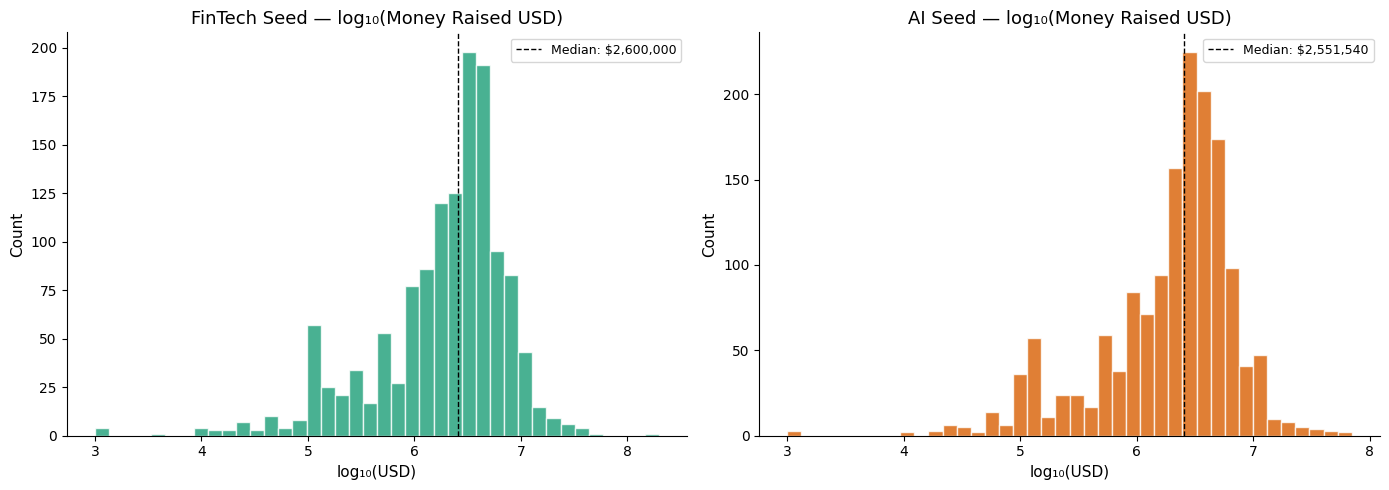

In [14]:
def parse_money(series):
    """Convert Crunchbase money strings ('$1,500,000') to float."""
    return (
        series.astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
        .apply(pd.to_numeric, errors="coerce")
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, df) in zip(axes, [("FinTech", ft_seed), ("AI", ai_seed)]):
    amounts = parse_money(df["Money Raised (in USD)"]).dropna()
    amounts_pos = amounts[amounts > 0]

    ax.hist(np.log10(amounts_pos), bins=40, color=COLORS[label], alpha=0.8, edgecolor="white")
    ax.set_title(f"{label} Seed — log₁₀(Money Raised USD)")
    ax.set_xlabel("log₁₀(USD)")
    ax.set_ylabel("Count")

    med = amounts_pos.median()
    ax.axvline(np.log10(med), color="black", linestyle="--", linewidth=1,
               label=f"Median: ${med:,.0f}")
    ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

In [15]:
# ── Summary statistics for seed amounts ──
for label, df in [("FinTech", ft_seed), ("AI", ai_seed)]:
    amounts = parse_money(df["Money Raised (in USD)"])
    print(f"── {label} Seed Amount (USD) ──")
    print(f"  N non-null:  {amounts.notna().sum():,}")
    print(f"  N zero:      {(amounts == 0).sum()}")
    print(f"  Min:         ${amounts.min():,.0f}")
    print(f"  25th pctl:   ${amounts.quantile(0.25):,.0f}")
    print(f"  Median:      ${amounts.median():,.0f}")
    print(f"  75th pctl:   ${amounts.quantile(0.75):,.0f}")
    print(f"  Max:         ${amounts.max():,.0f}")
    print(f"  Mean:        ${amounts.mean():,.0f}")
    print()

── FinTech Seed Amount (USD) ──
  N non-null:  1,335
  N zero:      0
  Min:         $1,000
  25th pctl:   $1,000,000
  Median:      $2,600,000
  75th pctl:   $4,500,000
  Max:         $200,000,000
  Mean:        $3,663,012

── AI Seed Amount (USD) ──
  N non-null:  1,532
  N zero:      0
  Min:         $1,000
  25th pctl:   $1,000,000
  Median:      $2,551,540
  75th pctl:   $4,500,000
  Max:         $70,000,000
  Mean:        $3,512,036



## 10. Organization Locations

The hazard model includes metro-region fixed effects. This section
examines the geographic concentration of startups.

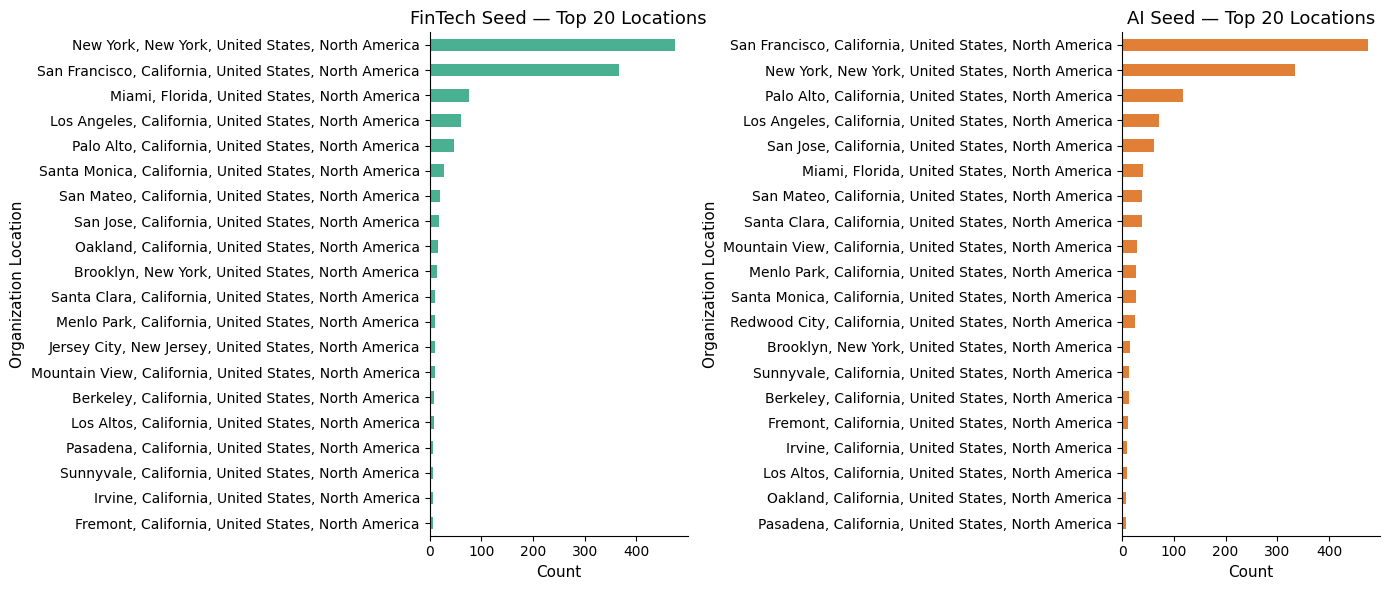

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (label, df) in zip(axes, [("FinTech", ft_seed), ("AI", ai_seed)]):
    top_locs = df["Organization Location"].value_counts().head(20)
    top_locs[::-1].plot.barh(ax=ax, color=COLORS[label], alpha=0.8)
    ax.set_title(f"{label} Seed — Top 20 Locations")
    ax.set_xlabel("Count")

fig.tight_layout()
plt.show()

In [17]:
# ── Extract city from 'Organization Location' to preview metro grouping ──
def extract_city_state(df):
    parts = df["Organization Location"].str.split(",", expand=True)
    return pd.DataFrame({
        "city":  parts[0].str.strip() if 0 in parts.columns else np.nan,
        "state": parts[1].str.strip() if 1 in parts.columns else np.nan,
    })

ft_locs = extract_city_state(ft_seed)
ai_locs = extract_city_state(ai_seed)

# Major metro proxies (cities that map to the 4 metro regions)
metro_cities = {
    "SFBA":  ["San Francisco", "Palo Alto", "San Jose", "Mountain View",
              "Sunnyvale", "Santa Clara", "Menlo Park", "San Mateo", "Redwood City"],
    "GNYA":  ["New York", "Brooklyn", "Jersey City", "Newark", "Hoboken"],
    "LA":    ["Los Angeles", "Santa Monica", "Irvine", "Beverly Hills", "Pasadena"],
    "Miami": ["Miami", "Fort Lauderdale", "Boca Raton", "West Palm Beach"],
}

def metro_summary(locs_df, label):
    city_col = locs_df["city"]
    total = len(city_col)
    print(f"── {label} metro distribution (approximate) ──")
    for metro, cities in metro_cities.items():
        n = city_col.isin(cities).sum()
        print(f"  {metro:6s}: {n:5,}  ({n/total*100:5.1f}%)")
    print()

metro_summary(ft_locs, "FinTech")
metro_summary(ai_locs, "AI")

── FinTech metro distribution (approximate) ──
  SFBA  :   491  ( 36.8%)
  GNYA  :   505  ( 37.8%)
  LA    :   104  (  7.8%)
  Miami :    87  (  6.5%)

── AI metro distribution (approximate) ──
  SFBA  :   825  ( 53.9%)
  GNYA  :   359  ( 23.4%)
  LA    :   117  (  7.6%)
  Miami :    48  (  3.1%)



## 11. Diversity Spotlight Flag

Crunchbase's `Diversity Spotlight` column is non-null for firms that
self-identify as having diverse founding teams. This becomes a binary
covariate in the hazard model.

In [18]:
for label, df in [("FinTech Seed", ft_seed), ("AI Seed", ai_seed),
                  ("FinTech Series A", ft_seriesa), ("AI Series A", ai_seriesa)]:
    if "Diversity Spotlight" in df.columns:
        n_flagged = df["Diversity Spotlight"].notna().sum()
        pct = n_flagged / len(df) * 100
        print(f"{label:20s}: {n_flagged:4,} / {len(df):,} flagged  ({pct:.1f}%)")

FinTech Seed        :  345 / 1,335 flagged  (25.8%)
AI Seed             :  393 / 1,532 flagged  (25.7%)
FinTech Series A    :  155 / 606 flagged  (25.6%)
AI Series A         :  328 / 683 flagged  (48.0%)


## 12. Investor Counts

`Number of Partner Investors` and `Number of Investors` are used as
covariates (log-transformed). Check their distributions.

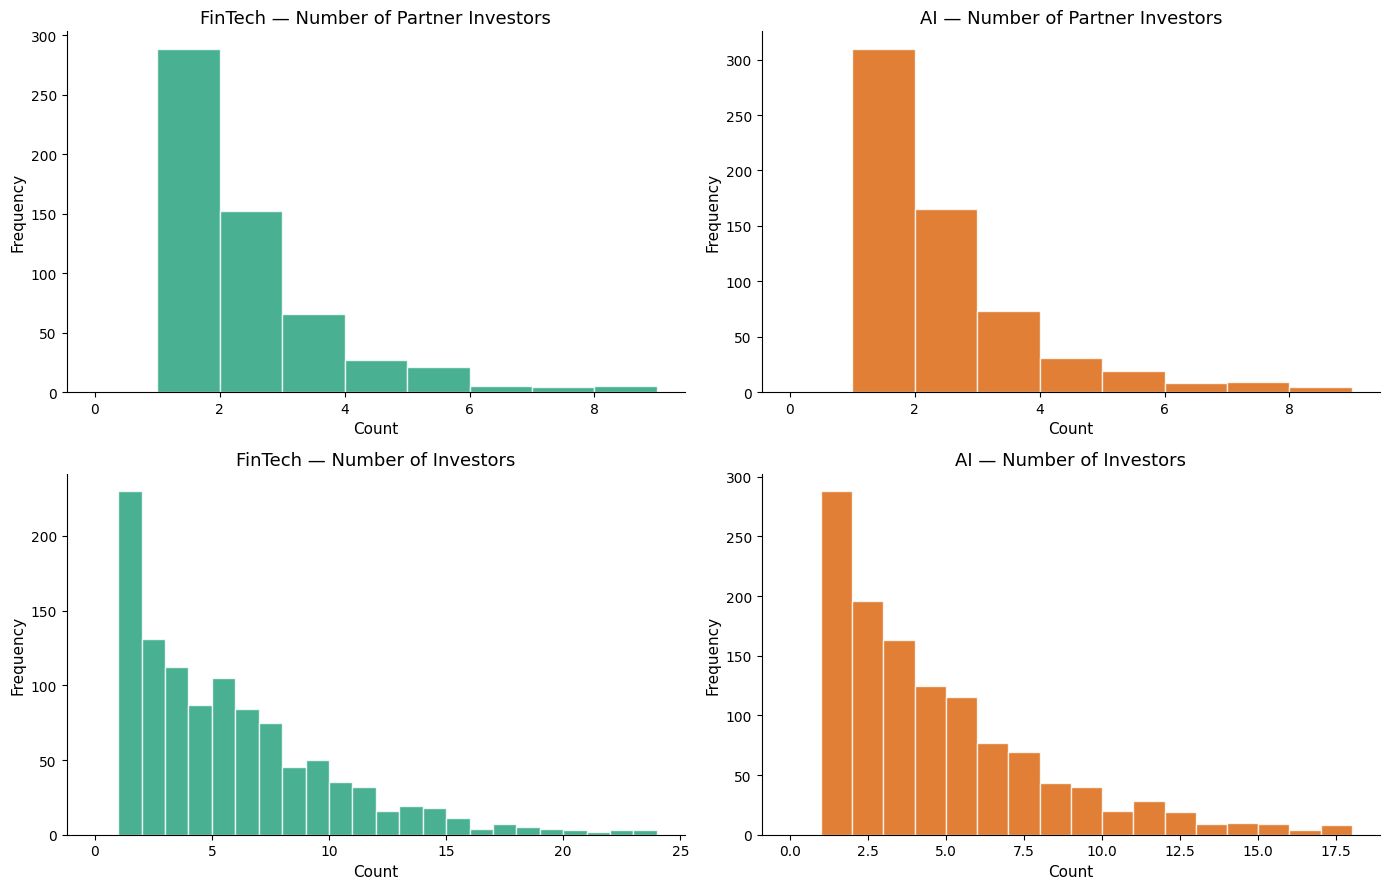

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for col_idx, col in enumerate(["Number of Partner Investors", "Number of Investors"]):
    for row_idx, (label, df) in enumerate([("FinTech", ft_seed), ("AI", ai_seed)]):
        ax = axes[col_idx, row_idx]
        vals = pd.to_numeric(df[col], errors="coerce").dropna()
        ax.hist(vals, bins=range(0, int(vals.quantile(0.99)) + 2),
                color=COLORS[label], alpha=0.8, edgecolor="white")
        ax.set_title(f"{label} — {col}")
        ax.set_xlabel("Count")
        ax.set_ylabel("Frequency")

fig.tight_layout()
plt.show()

## 13. Cross-Sector Comparison Summary

Side-by-side summary to confirm the two sectors are comparable enough
to pool in the same hazard model.

In [20]:
def sector_summary(seed_df, sa_df, label):
    seed_dates = pd.to_datetime(seed_df["Announced Date"], errors="coerce")
    amounts = parse_money(seed_df["Money Raised (in USD)"])
    n_seed_orgs = seed_df["Organization Name"].nunique()
    n_sa_orgs = sa_df["Organization Name"].nunique()
    matched = set(seed_df["Organization Name"]) & set(sa_df["Organization Name"])
    return {
        "Sector": label,
        "Seed transactions": len(seed_df),
        "Unique seed orgs": n_seed_orgs,
        "Series A transactions": len(sa_df),
        "Seed→A match rate": f"{len(matched)/n_seed_orgs*100:.1f}%",
        "Date range": f"{seed_dates.min():%Y-%m} to {seed_dates.max():%Y-%m}",
        "Median seed ($)": f"${amounts.median():,.0f}",
        "Diversity flag %": f"{seed_df['Diversity Spotlight'].notna().mean()*100:.1f}%",
    }

summary = pd.DataFrame([
    sector_summary(ft_seed, ft_seriesa, "FinTech"),
    sector_summary(ai_seed, ai_seriesa, "AI"),
]).set_index("Sector").T

print(summary.to_string())

Sector                            FinTech                  AI
Seed transactions                    1335                1532
Unique seed orgs                     1034                1173
Series A transactions                 606                 683
Seed→A match rate                   35.7%               34.9%
Date range             2016-01 to 2024-12  2016-01 to 2024-12
Median seed ($)                $2,600,000          $2,551,540
Diversity flag %                    25.8%               25.7%


---

# Part B — Macro Environment

These three series form the macro backbone of the hazard model.
The monetary policy shock is the **core independent variable**; Core CPI
and Real GDP growth provide economic context and can serve as controls
or instruments for understanding the transmission channel.

## 14. Load & Inspect Macro Data

In [21]:
# ── Helper: convert monetary shock quarter labels to timestamps ──
def qlabel_to_timestamp(s):
    """'2018-Q4' → pd.Timestamp('2018-10-01')"""
    s = str(s).strip().replace("-", "")
    return pd.Period(s, freq="Q-DEC").to_timestamp()

# ── Monetary policy shocks ──
shock = pd.read_csv(RAW_MACRO / "monetary_shock.csv")
shock["date"] = shock["quarter_year"].map(qlabel_to_timestamp)
shock = shock.sort_values("date").reset_index(drop=True)

# ── Core CPI (YoY % change) ──
cpi = pd.read_csv(RAW_MACRO / "core_cpi.csv")
cpi["date"] = pd.to_datetime(cpi["observation_date"])
cpi = cpi.sort_values("date").reset_index(drop=True)

# ── Real GDP (YoY % change) ──
gdp = pd.read_csv(RAW_MACRO / "real_gdp.csv")
gdp["date"] = pd.to_datetime(gdp["observation_date"])
gdp = gdp.sort_values("date").reset_index(drop=True)

macro_files = {"Monetary Shock": shock, "Core CPI": cpi, "Real GDP": gdp}

for name, df in macro_files.items():
    print(f"{name:18s} →  {len(df):3} rows  |  "
          f"{df['date'].min():%Y-Q}{(df['date'].min().month-1)//3+1}  to  "
          f"{df['date'].max():%Y-Q}{(df['date'].max().month-1)//3+1}  |  "
          f"cols: {list(df.columns)}")

Monetary Shock     →   39 rows  |  2014-Q1  to  2023-Q3  |  cols: ['quarter_year', 'mps_shock', 'date']
Core CPI           →   43 rows  |  2015-Q1  to  2025-Q3  |  cols: ['observation_date', 'CPILFESL_PC1', 'date']
Real GDP           →   43 rows  |  2015-Q1  to  2025-Q3  |  cols: ['observation_date', 'GDPC1_PC1', 'date']


In [22]:
# ── Preview each file ──
print("── Monetary Shocks (first 8 rows) ──")
print(shock[["quarter_year", "mps_shock", "date"]].head(8).to_string(index=False))
print()
print("── Core CPI (first 8 rows) ──")
print(cpi[["observation_date", "CPILFESL_PC1", "date"]].head(8).to_string(index=False))
print()
print("── Real GDP (first 8 rows) ──")
print(gdp[["observation_date", "GDPC1_PC1", "date"]].head(8).to_string(index=False))

── Monetary Shocks (first 8 rows) ──
quarter_year  mps_shock       date
     2014-Q1     0.0339 2014-01-01
     2014-Q2     0.0283 2014-04-01
     2014-Q3     0.0273 2014-07-01
     2014-Q4    -0.0199 2014-10-01
     2015-Q1    -0.0662 2015-01-01
     2015-Q2    -0.0324 2015-04-01
     2015-Q3    -0.0616 2015-07-01
     2015-Q4     0.0819 2015-10-01

── Core CPI (first 8 rows) ──
observation_date  CPILFESL_PC1       date
      2015-01-01       1.68842 2015-01-01
      2015-04-01       1.77700 2015-04-01
      2015-07-01       1.86081 2015-07-01
      2015-10-01       1.99420 2015-10-01
      2016-01-01       2.17000 2016-01-01
      2016-04-01       2.22453 2016-04-01
      2016-07-01       2.25004 2016-07-01
      2016-10-01       2.18236 2016-10-01

── Real GDP (first 8 rows) ──
observation_date  GDPC1_PC1       date
      2015-01-01    3.96930 2015-01-01
      2015-04-01    3.27909 2015-04-01
      2015-07-01    2.44732 2015-07-01
      2015-10-01    2.11986 2015-10-01
      2016-01

## 15. Macro Coverage vs. Observation Window

The startup panel runs 2016 Q1 – 2023 Q3 (31 quarters). Every quarter
in that window must have a macro observation, or the panel merge will
introduce NaN gaps.

In [23]:
# Build the set of quarters the panel needs
panel_quarters = pd.date_range(OBS_START, OBS_END, freq="QS")  # quarter starts

print(f"Panel requires {len(panel_quarters)} quarters: "
      f"{panel_quarters[0]:%Y-Q1} to {panel_quarters[-1]:%Y-Q}{(panel_quarters[-1].month-1)//3+1}")
print()

for name, df, col in [
    ("Monetary Shock", shock, "mps_shock"),
    ("Core CPI",       cpi,   "CPILFESL_PC1"),
    ("Real GDP",       gdp,   "GDPC1_PC1"),
]:
    available = set(df["date"])
    missing = sorted(set(panel_quarters) - available)
    extra_before = df[df["date"] < OBS_START]
    extra_after  = df[df["date"] > OBS_END]

    status = "✓  Full coverage" if not missing else f"⚠  MISSING {len(missing)} quarter(s)"
    print(f"── {name} ──")
    print(f"  Panel coverage:    {status}")
    if missing:
        print(f"  Missing quarters:  {[f'{d:%Y-Q}' + str((d.month-1)//3+1) for d in missing]}")
    print(f"  Extra pre-window:  {len(extra_before)} quarters")
    print(f"  Extra post-window: {len(extra_after)} quarters")
    print(f"  NaN values in {col}: {df[col].isna().sum()}")
    print()

Panel requires 31 quarters: 2016-Q1 to 2023-Q3

── Monetary Shock ──
  Panel coverage:    ✓  Full coverage
  Extra pre-window:  8 quarters
  Extra post-window: 0 quarters
  NaN values in mps_shock: 0

── Core CPI ──
  Panel coverage:    ✓  Full coverage
  Extra pre-window:  4 quarters
  Extra post-window: 8 quarters
  NaN values in CPILFESL_PC1: 0

── Real GDP ──
  Panel coverage:    ✓  Full coverage
  Extra pre-window:  4 quarters
  Extra post-window: 8 quarters
  NaN values in GDPC1_PC1: 0



## 16. Macro Summary Statistics

In [25]:
# Filter each series to the observation window for comparable stats
shock_w = shock[(shock["date"] >= OBS_START) & (shock["date"] <= OBS_END)].copy()
cpi_w   = cpi[(cpi["date"] >= OBS_START) & (cpi["date"] <= OBS_END)].copy()
gdp_w   = gdp[(gdp["date"] >= OBS_START) & (gdp["date"] <= OBS_END)].copy()

stats = pd.DataFrame({
    "MP Shock (raw)": shock_w["mps_shock"].describe(),
    "MP Shock (25bp units)": (shock_w["mps_shock"] / 0.25).describe(),
    "Core CPI (YoY %)": cpi_w["CPILFESL_PC1"].describe(),
    "Real GDP (YoY %)": gdp_w["GDPC1_PC1"].describe(),
}).round(4)

print("── Summary statistics within observation window (2016 Q1 – 2023 Q3) ──")
print(stats.to_string())

── Summary statistics within observation window (2016 Q1 – 2023 Q3) ──
       MP Shock (raw)  MP Shock (25bp units)  Core CPI (YoY %)  Real GDP (YoY %)
count         31.0000                31.0000           31.0000           31.0000
mean           0.0108                 0.0432            3.0452            2.4053
std            0.0983                 0.3932            1.6554            2.8957
min           -0.4054                -1.6216            1.2776           -7.3986
25%           -0.0003                -0.0014            2.0050            1.8033
50%            0.0183                 0.0732            2.2231            2.3304
75%            0.0524                 0.2096            4.2297            3.1816
max            0.1447                 0.5788            6.3309           12.3857


## 17. Macro Time-Series Plots

Visualize each series across the full available range, with the
observation window shaded. This reveals the macro regimes that startups
in the sample experienced.

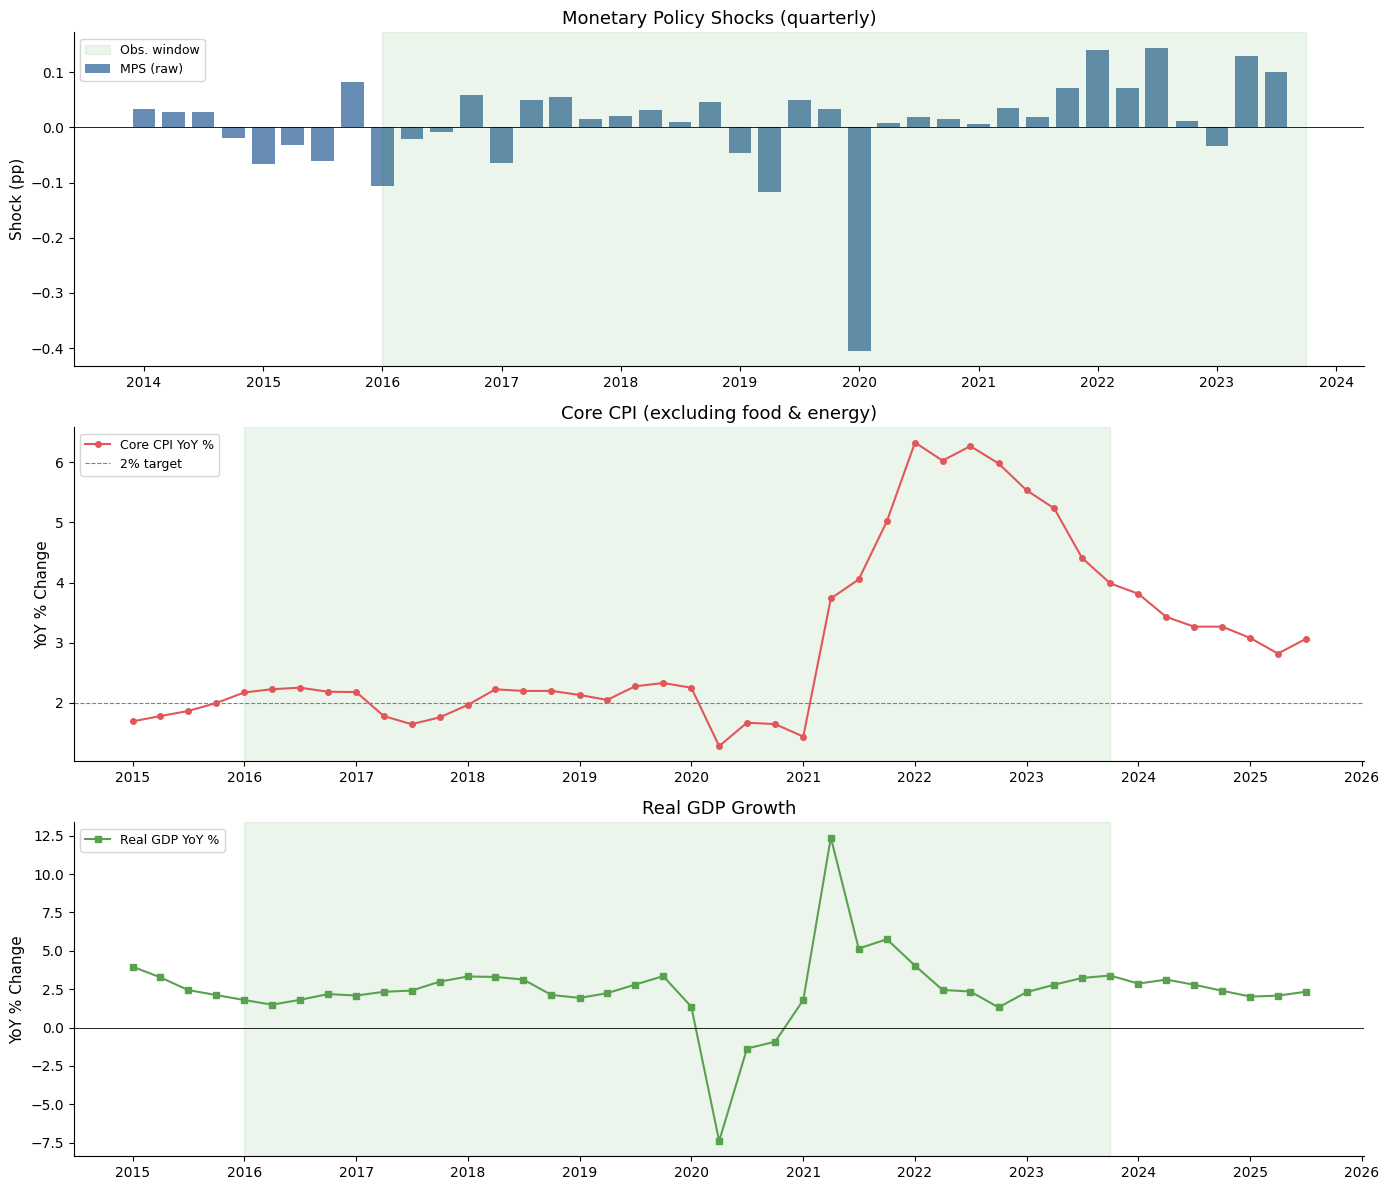

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

# ── Panel 1: Monetary Policy Shocks ──
ax = axes[0]
ax.bar(shock["date"], shock["mps_shock"], width=70, color="#4e79a7", alpha=0.85, label="MPS (raw)")
ax.axhline(0, color="black", linewidth=0.6)
ax.axvspan(OBS_START, OBS_END, alpha=0.08, color="green", label="Obs. window")
ax.set_ylabel("Shock (pp)")
ax.set_title("Monetary Policy Shocks (quarterly)")
ax.legend(loc="upper left", fontsize=9)

# ── Panel 2: Core CPI ──
ax = axes[1]
ax.plot(cpi["date"], cpi["CPILFESL_PC1"], marker="o", markersize=4,
        color="#e15759", linewidth=1.5, label="Core CPI YoY %")
ax.axhline(2.0, color="gray", linestyle="--", linewidth=0.8, label="2% target")
ax.axvspan(OBS_START, OBS_END, alpha=0.08, color="green")
ax.set_ylabel("YoY % Change")
ax.set_title("Core CPI (excluding food & energy)")
ax.legend(loc="upper left", fontsize=9)

# ── Panel 3: Real GDP ──
ax = axes[2]
ax.plot(gdp["date"], gdp["GDPC1_PC1"], marker="s", markersize=4,
        color="#59a14f", linewidth=1.5, label="Real GDP YoY %")
ax.axhline(0, color="black", linewidth=0.6)
ax.axvspan(OBS_START, OBS_END, alpha=0.08, color="green")
ax.set_ylabel("YoY % Change")
ax.set_title("Real GDP Growth")
ax.legend(loc="upper left", fontsize=9)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=0)

fig.tight_layout()
plt.show()

## 18. Macro Overlay — Shocks in Context

Plot all three series on a shared time axis to see how monetary shocks
relate to inflation and growth cycles. This is the economic story that
motivates the research question: do contractionary shocks during periods
of high inflation / slowing growth delay startup progression differently?

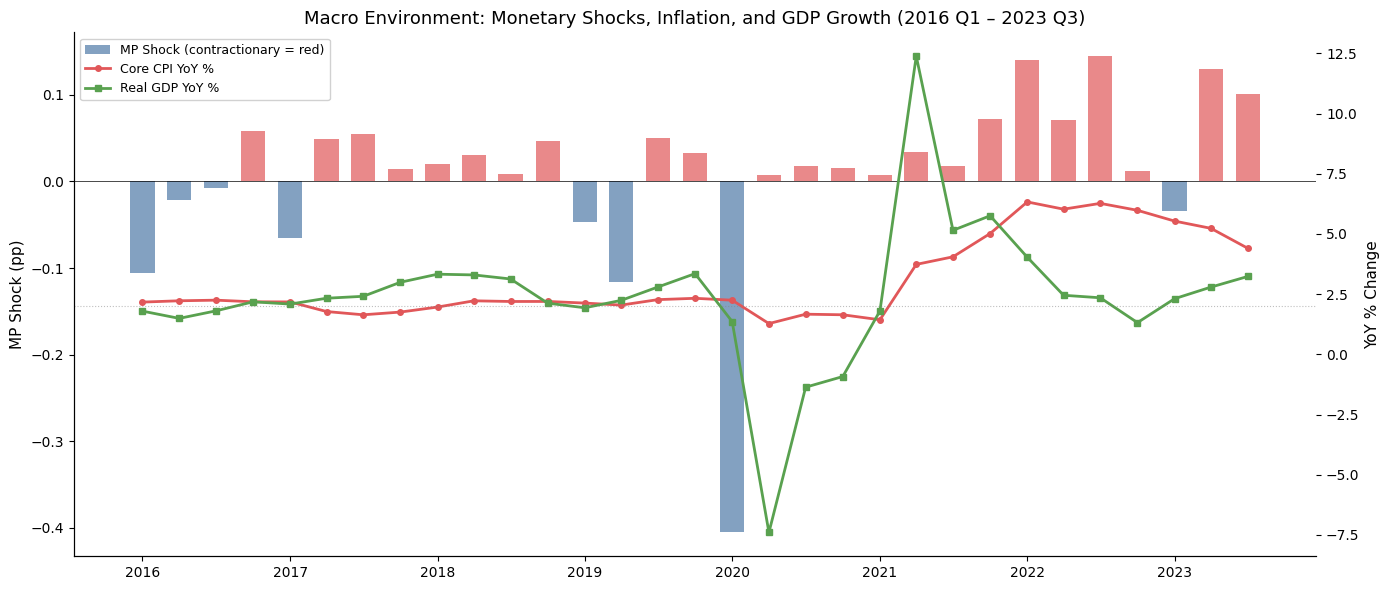

In [27]:
# Merge all three on date (within observation window)
macro = (
    shock_w[["date", "mps_shock"]]
    .merge(cpi_w[["date", "CPILFESL_PC1"]], on="date", how="outer")
    .merge(gdp_w[["date", "GDPC1_PC1"]], on="date", how="outer")
    .sort_values("date")
)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart for shocks
colors = ["#e15759" if v > 0 else "#4e79a7" for v in macro["mps_shock"].fillna(0)]
ax1.bar(macro["date"], macro["mps_shock"], width=60, color=colors, alpha=0.7,
        label="MP Shock (contractionary = red)")
ax1.set_ylabel("MP Shock (pp)", fontsize=11)
ax1.axhline(0, color="black", linewidth=0.5)

# Overlay CPI and GDP on secondary axis
ax2 = ax1.twinx()
ax2.plot(macro["date"], macro["CPILFESL_PC1"], color="#e15759", linewidth=2,
         linestyle="-", marker="o", markersize=4, label="Core CPI YoY %")
ax2.plot(macro["date"], macro["GDPC1_PC1"], color="#59a14f", linewidth=2,
         linestyle="-", marker="s", markersize=4, label="Real GDP YoY %")
ax2.set_ylabel("YoY % Change", fontsize=11)
ax2.axhline(2.0, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9,
           framealpha=0.9)

ax1.set_title("Macro Environment: Monetary Shocks, Inflation, and GDP Growth (2016 Q1 – 2023 Q3)",
              fontsize=13)
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
plt.show()

## 19. Macro Variable Distributions

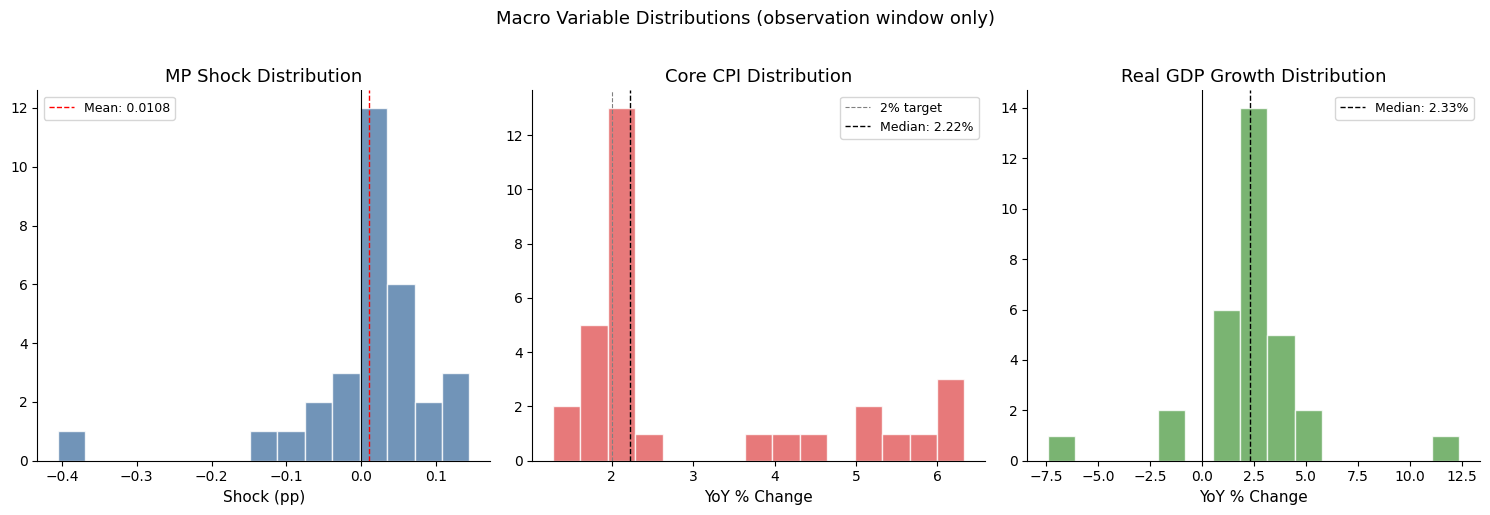

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Monetary Shock ──
ax = axes[0]
ax.hist(shock_w["mps_shock"], bins=15, color="#4e79a7", alpha=0.8, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(shock_w["mps_shock"].mean(), color="red", linestyle="--", linewidth=1,
           label=f"Mean: {shock_w['mps_shock'].mean():.4f}")
ax.set_title("MP Shock Distribution")
ax.set_xlabel("Shock (pp)")
ax.legend(fontsize=9)

# ── Core CPI ──
ax = axes[1]
ax.hist(cpi_w["CPILFESL_PC1"], bins=15, color="#e15759", alpha=0.8, edgecolor="white")
ax.axvline(2.0, color="gray", linestyle="--", linewidth=0.8, label="2% target")
ax.axvline(cpi_w["CPILFESL_PC1"].median(), color="black", linestyle="--", linewidth=1,
           label=f"Median: {cpi_w['CPILFESL_PC1'].median():.2f}%")
ax.set_title("Core CPI Distribution")
ax.set_xlabel("YoY % Change")
ax.legend(fontsize=9)

# ── Real GDP ──
ax = axes[2]
ax.hist(gdp_w["GDPC1_PC1"], bins=15, color="#59a14f", alpha=0.8, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(gdp_w["GDPC1_PC1"].median(), color="black", linestyle="--", linewidth=1,
           label=f"Median: {gdp_w['GDPC1_PC1'].median():.2f}%")
ax.set_title("Real GDP Growth Distribution")
ax.set_xlabel("YoY % Change")
ax.legend(fontsize=9)

fig.suptitle("Macro Variable Distributions (observation window only)", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 20. Macro Correlations

Check pairwise correlations among the three macro series. High
correlation between the shock and CPI/GDP would raise concerns about
multicollinearity in the hazard model.

── Pairwise Pearson Correlations (observation window) ──
          MP Shock  Core CPI  Real GDP
MP Shock     1.000     0.392     0.168
Core CPI     0.392     1.000     0.335
Real GDP     0.168     0.335     1.000



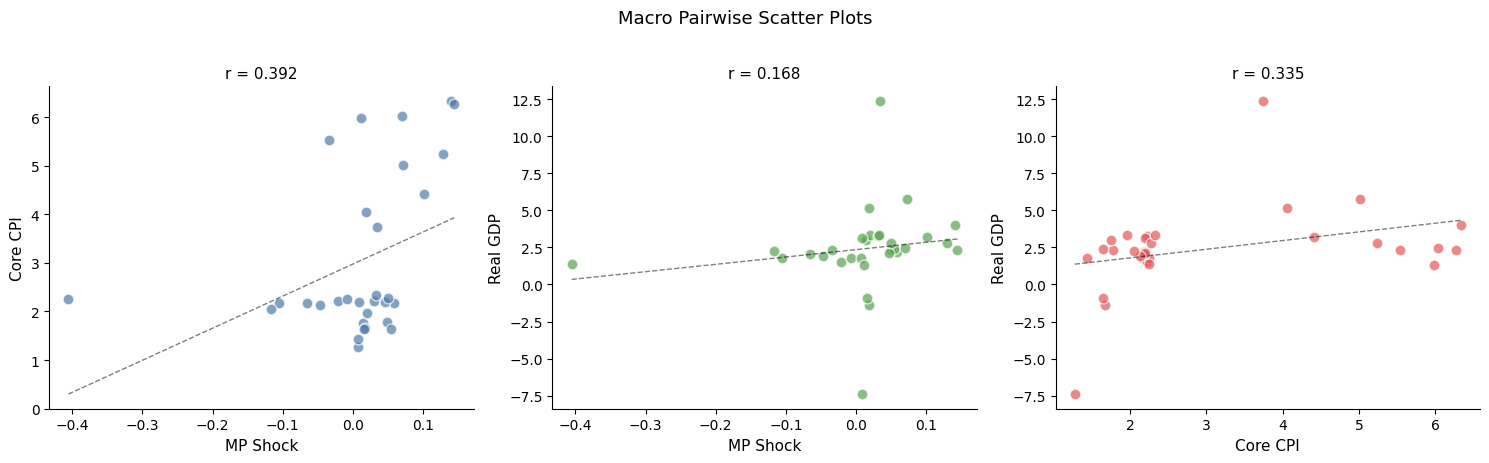

In [29]:
corr_df = macro[["mps_shock", "CPILFESL_PC1", "GDPC1_PC1"]].rename(columns={
    "mps_shock": "MP Shock",
    "CPILFESL_PC1": "Core CPI",
    "GDPC1_PC1": "Real GDP",
})

corr_matrix = corr_df.corr().round(3)
print("── Pairwise Pearson Correlations (observation window) ──")
print(corr_matrix.to_string())
print()

# Scatter matrix
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

pairs = [("MP Shock", "Core CPI"), ("MP Shock", "Real GDP"), ("Core CPI", "Real GDP")]
colors_scatter = ["#4e79a7", "#59a14f", "#e15759"]

for ax, (x, y), c in zip(axes, pairs, colors_scatter):
    ax.scatter(corr_df[x], corr_df[y], alpha=0.7, color=c, edgecolors="white", s=60)
    r = corr_df[x].corr(corr_df[y])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"r = {r:.3f}", fontsize=11)

    # trend line
    m, b = np.polyfit(corr_df[x].dropna(), corr_df[y].dropna(), 1)
    x_line = np.linspace(corr_df[x].min(), corr_df[x].max(), 50)
    ax.plot(x_line, m * x_line + b, color="black", linewidth=1, linestyle="--", alpha=0.5)

fig.suptitle("Macro Pairwise Scatter Plots", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

---

# Part C — Key Takeaways & Flags for Cleaning

After reviewing the raw startup and macro data, note any issues to
address in `02_data_cleaning.ipynb`:

**Startup data**

1. **Package overlap** — Check the overlap counts above. If packages A and B share rows, deduplication is needed during the merge step.
2. **Funding Type contamination** — If any non-Seed or non-Series A types appear, they must be filtered out.
3. **Date range spill** — Rows outside 2016-01-01 to 2023-09-30 exist in the raw data. The panel construction notebook handles the observation window, but be aware of it.
4. **Money Raised parsing** — The column contains dollar-formatted strings (`$1,500,000`). Parse to numeric during cleaning, not at model time.
5. **Location granularity** — City names alone can collide across states (e.g., Portland, OR vs Portland, ME). The metro mapping should include state.
6. **AI Series A has an `.xlsx` file** — One of the AI Series A packages is Excel, not CSV. The cleaning notebook must handle both formats.
7. **Multiple seed rounds per org** — Some startups appear more than once. The cleaning notebook should collapse to the earliest seed round per org.

**Macro data**

8. **Observation window alignment** — Verify all three macro series fully cover 2016 Q1 – 2023 Q3 with no gaps. CPI and GDP extend beyond the window (through 2025) — trim during the panel merge.
9. **Shock units** — The raw `mps_shock` column is in percentage points. Notebook `05` converts to 25bp units (`mps_shock / 0.25`). Decide which unit to standardize on and apply it once. 
10. **Date key formats differ** — Monetary shocks use `quarter_year` (e.g., "2018-Q4") while CPI/GDP use `observation_date` (e.g., "2018-10-01"). The panel merge must reconcile these. 
11. **Multicollinearity** — Check the correlation matrix above. If Core CPI or GDP are highly correlated with the shock, consider whether to include them as controls or discuss in the robustness section.
12. **COVID quarters** — 2020 Q1–Q2 show extreme GDP moves. The hazard model should be tested with and without these quarters.

Review the plots and counts above, then proceed to `02_data_cleaning.ipynb`.